In this notebook Seamese network model for handwriting author verification trained. As backup vit_base_patch16_224 model used, loss function - triplet loss.

In [2]:
#importing dataset
!pip install -q gdown

file_id = "1YomoMVLtK0WG_GXV_B8Wd5OitzS-ObHi"
output_name = "all_data_2.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1YomoMVLtK0WG_GXV_B8Wd5OitzS-ObHi
From (redirected): https://drive.google.com/uc?id=1YomoMVLtK0WG_GXV_B8Wd5OitzS-ObHi&confirm=t&uuid=c96e4281-51b5-4bba-8884-428566dcf995
To: /kaggle/working/all_data_2.zip
100%|███████████████████████████████████████| 1.71G/1.71G [00:13<00:00, 128MB/s]


In [3]:
import zipfile
import os

with zipfile.ZipFile("all_data_2.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

# Посмотрите, что получилось
os.listdir("/kaggle/working/")

['all_data_2.zip', 'all_data_2', '.virtual_documents']

In [4]:
!pip install torchvision

In [5]:
!pip install timm

In [6]:
import os
from pathlib import Path
import cv2
import numpy as np
import shutil
import random
import torch

from torch.utils.data import Dataset
import PIL
from PIL import Image
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader

import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import zipfile
import os
import timm
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR


In [7]:
def set_seed(seed=42):
    """Fix all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"All seeds fixed to {seed}")
set_seed(42)

All seeds fixed to 42


In [30]:
#reference to our dataset
DATA_ROOT = "/kaggle/working/all_data_2"

Let's create class of our dataset. The dataset os combination of IAM and Cedar datasets.
The documents in IAM dataset are patched into lines. The CEDAR datset is used without changes.
The dataset creates triplets of images:
from IAM dataset, for positive example taken image of the same author, for negative - image of other author;
from CEDAR dataset, for positive example taken image of signature of the same author, for negative - image of forgery of signature of this author.
The dataset allows to control the ratio of data from CEDAR and IAM datasets, as default the ratio is 50/50.
The triplets are created 'on the fly'.

In [38]:
class TripletDataset(Dataset):
    def __init__(self, root, transform=None, size=100,
                 min_height=50, max_height=500, authors_list=None,
                 cedar_ratio=0.5):
        """
        Dataset for Triplet Loss with multiple data sources (IAM and CEDAR).

        Args:
            root: Root directory containing 'iam' and 'cedar' folders
            transform: Image transformations
            size: Number of triplets per epoch
            min_height: Minimum image height filter
            max_height: Maximum image height filter
            authors_list: List of author IDs to include (for train/val split)
            cedar_ratio: Probability of sampling triplet from CEDAR (0.5 = 50%)
        """
        self.transform = transform
        self.size = size
        self.min_height = min_height
        self.max_height = max_height
        self.cedar_ratio = cedar_ratio

        # Separate data structures for IAM and CEDAR
        self.iam_data = {}      # author_id -> list of image paths (IAM)
        self.cedar_original = {} # author_id -> list of original signatures
        self.cedar_forgery = {}  # author_id -> list of forgery signatures

        # Scan IAM folder (handwriting lines)
        iam_path = os.path.join(root, 'iam')
        if os.path.exists(iam_path):
            for folder in os.listdir(iam_path):
                author_path = os.path.join(iam_path, folder)
                if not os.path.isdir(author_path):
                    continue

                author_id = folder
                valid_images = []
                for file in os.listdir(author_path):
                    if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        continue

                    img_path = os.path.join(author_path, file)
                    try:
                        with Image.open(img_path) as img:
                            height = img.size[1]
                        if self.min_height <= height <= self.max_height:
                            valid_images.append(img_path)
                    except Exception:
                        continue

                if valid_images:
                    self.iam_data[author_id] = valid_images

        # Scan CEDAR folder (signatures)
        cedar_path = os.path.join(root, 'cedar')
        if os.path.exists(cedar_path):
            # Scan original signatures
            original_path = os.path.join(cedar_path, 'original')
            if os.path.exists(original_path):
                for folder in os.listdir(original_path):
                    author_path = os.path.join(original_path, folder)
                    if not os.path.isdir(author_path):
                        continue

                    author_id = folder
                    valid_images = []
                    for file in os.listdir(author_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                            continue

                        img_path = os.path.join(author_path, file)
                        try:
                            with Image.open(img_path) as img:
                                height = img.size[1]
                            if self.min_height <= height <= self.max_height:
                                valid_images.append(img_path)
                        except Exception:
                            continue

                    if valid_images:
                        self.cedar_original[author_id] = valid_images

            # Scan forgery signatures
            forgery_path = os.path.join(cedar_path, 'forgery')
            if os.path.exists(forgery_path):
                for folder in os.listdir(forgery_path):
                    author_path = os.path.join(forgery_path, folder)
                    if not os.path.isdir(author_path):
                        continue

                    author_id = folder
                    valid_images = []
                    for file in os.listdir(author_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                            continue

                        img_path = os.path.join(author_path, file)
                        try:
                            with Image.open(img_path) as img:
                                height = img.size[1]
                            if self.min_height <= height <= self.max_height:
                                valid_images.append(img_path)
                        except Exception:
                            continue

                    if valid_images:
                        self.cedar_forgery[author_id] = valid_images

        # Filter authors based on authors_list (if provided)
        if authors_list is not None:
            author_set = set(authors_list)
            self.iam_data = {k: v for k, v in self.iam_data.items() if k in author_set}
            self.cedar_original = {k: v for k, v in self.cedar_original.items() if k in author_set}
            self.cedar_forgery = {k: v for k, v in self.cedar_forgery.items() if k in author_set}

        # Build lists of authors with sufficient data
        self.iam_authors = [a for a, imgs in self.iam_data.items() if len(imgs) >= 2]
        self.cedar_authors = [a for a in self.cedar_original.keys() if len(self.cedar_original.get(a, [])) >= 2]

        # For CEDAR, authors need at least one forgery for negative sampling
        self.cedar_authors_with_forgery = [a for a in self.cedar_authors if a in self.cedar_forgery and self.cedar_forgery[a]]

        # All authors for negative sampling (any author with at least 1 image)
        self.iam_all_authors = list(self.iam_data.keys())
        self.cedar_all_authors = list(self.cedar_original.keys())

    def __len__(self):
        return self.size

    def _get_iam_triplet(self):
        """Create triplet from IAM dataset (handwriting lines)."""
        # Anchor and Positive: same author
        author = random.choice(self.iam_authors)
        images = self.iam_data[author]
        anchor_path, positive_path = random.sample(images, 2)

        # Negative: different author
        if len(self.iam_all_authors) < 2:
            negative_author = author
            negative_images = [p for p in images if p != anchor_path and p != positive_path]
            if not negative_images:
                negative_images = images
            negative_path = random.choice(negative_images)
        else:
            negative_author = random.choice(self.iam_all_authors)
            while negative_author == author:
                negative_author = random.choice(self.iam_all_authors)
            negative_path = random.choice(self.iam_data[negative_author])

        return anchor_path, positive_path, negative_path

    def _get_cedar_triplet(self):
        """
        Create triplet from CEDAR dataset.
        Anchor and Positive: two different original signatures from same author.
        Negative: forgery signature of the SAME author.
        """
        # Anchor and Positive: same author, two different original signatures
        author = random.choice(self.cedar_authors_with_forgery)
        original_images = self.cedar_original[author]
        anchor_path, positive_path = random.sample(original_images, 2)

        # Negative: forgery of the SAME author
        forgery_images = self.cedar_forgery[author]
        negative_path = random.choice(forgery_images)

        return anchor_path, positive_path, negative_path

    def __getitem__(self, idx):
        # Decide which dataset to sample from based on cedar_ratio
        use_cedar = random.random() < self.cedar_ratio

        if use_cedar and self.cedar_authors_with_forgery:
            anchor_path, positive_path, negative_path = self._get_cedar_triplet()
        else:
            # Fallback to IAM if CEDAR not available
            anchor_path, positive_path, negative_path = self._get_iam_triplet()

        # Load images
        anchor = Image.open(anchor_path).convert('L')
        positive = Image.open(positive_path).convert('L')
        negative = Image.open(negative_path).convert('L')

        if self.transform:
            anchor = self.transform(anchor)
            positive = self.transform(positive)
            negative = self.transform(negative)

        return anchor, positive, negative

Separating the authors into train and validation

In [41]:
iam_path = os.path.join(DATA_ROOT, 'iam')
cedar_path = os.path.join(DATA_ROOT, 'cedar', 'original')

iam_authors = os.listdir(iam_path) if os.path.exists(iam_path) else []
cedar_authors = os.listdir(cedar_path) if os.path.exists(cedar_path) else []

all_authors = list(set(iam_authors + cedar_authors))
print(f"IAM authors: {len(iam_authors)}")
print(f"CEDAR authors: {len(cedar_authors)}")
print(f"Total unique authors: {len(all_authors)}")

random.shuffle(all_authors)
split_idx = int(len(all_authors) * 0.8)
train_authors = all_authors[:split_idx]
val_authors = all_authors[split_idx:]

print(f"Train authors: {len(train_authors)}")
print(f"Val authors: {len(val_authors)}")

IAM authors: 657
CEDAR authors: 55
Total unique authors: 657
Train authors: 525
Val authors: 132


Creating tranformations, datasets and dataloaders. Since we will use the model which takes 224*224 images, we resize all images into 224*224

In [42]:
train_transform_all_data_224 = T.Compose([
    T.Resize((224, 224)),  #use 224*224 for the model
    T.RandomRotation(3),
    T.RandomAffine(0, translate=(0.02, 0.02), scale=(0.98, 1.02)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

val_transform_all_data_224 = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

In [43]:
#create dataset
train_dataset_all_224 = TripletDataset(
    root=DATA_ROOT,
    transform=train_transform_all_data_224,
    size=5000,
    min_height=50,
    max_height=500,
    authors_list=train_authors,
    cedar_ratio=0.5
)

val_dataset_all_224 = TripletDataset(
    root=DATA_ROOT,
    transform=val_transform_all_data_224,
    size=2000,
    min_height=50,
    max_height=500,
    authors_list=val_authors,
    cedar_ratio=0.5
)

# Create dataloaders
train_loader_all_224 = DataLoader(
    train_dataset_all_224,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader_all_224 = DataLoader(
    val_dataset_all_224,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


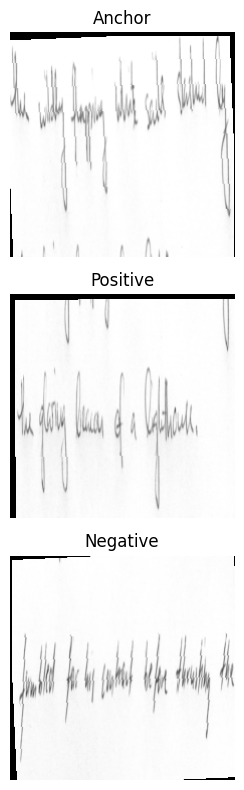

In [44]:
#Let's look at an example of data
anchor, positive, negative= train_dataset_all_224[0]

plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.imshow(anchor[0], cmap='gray')
plt.title(f"Anchor")
plt.axis('off')

plt.subplot(3, 1, 2)
plt.imshow(positive[0], cmap='gray')
plt.title("Positive")
plt.axis('off')

plt.subplot(3, 1, 3)
plt.imshow(negative[0], cmap='gray')
plt.title("Negative")
plt.axis('off')

plt.tight_layout()
plt.show()

Now let's create class of our model. The model uses triplet loss and vit_base_patch16_224 model. The class allows to use 'aggressive' mode for freezing layers, namely freeze all layers except for 2 last. If the mode is not 'aggressive', all layers are trained 

In [ ]:
class TripletNetwork(nn.Module):
    def __init__(self, embedding_size=256, model_name='vit_base_patch16_224',
                 pretrained=True, freeze_mode="aggressive"):
        super(TripletNetwork, self).__init__()

        # Load ViT
        self.vit = timm.create_model(model_name, pretrained=pretrained)

        # Adapt first layer for 1 channel
        old_conv = self.vit.patch_embed.proj
        new_conv = nn.Conv2d(1, old_conv.out_channels,
                             kernel_size=old_conv.kernel_size,
                             stride=old_conv.stride,
                             padding=old_conv.padding,
                             bias=False)
        with torch.no_grad():
            new_conv.weight.data = old_conv.weight.data.mean(dim=1, keepdim=True)
        self.vit.patch_embed.proj = new_conv

        # Remove classifier head
        if hasattr(self.vit, 'head'):
            in_features = self.vit.head.in_features
            self.vit.head = nn.Identity()
        else:
            in_features = self.vit.num_features

        # Freeze layers (optional)
        if freeze_mode == "aggressive":
            for param in self.vit.parameters():
                param.requires_grad = False
            # Unfreeze last blocks
            for i, block in enumerate(self.vit.blocks):
                if i >= len(self.vit.blocks) - 2:
                    for param in block.parameters():
                        param.requires_grad = True
            for param in self.vit.norm.parameters():
                param.requires_grad = True
            for param in self.vit.patch_embed.proj.parameters():
                param.requires_grad = True

        # Embedding head (projects features to embedding space)
        self.embedding = nn.Sequential(
            nn.Linear(in_features, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, embedding_size)
        )

        self.embedding_size = embedding_size

        # Statistics
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Total parameters: {total:,}")
        print(f"Trainable parameters: {trainable:,} ({100*trainable/total:.1f}%)")

    def forward_one(self, x):
        x = self.vit(x)
        x = self.embedding(x)
        return F.normalize(x, p=2, dim=1)  # L2 normalize for stable training

    def forward(self, anchor, positive, negative):
        # Getting embeddings for all 3 inputimages
        emb_anchor = self.forward_one(anchor)
        emb_positive = self.forward_one(positive)
        emb_negative = self.forward_one(negative)

        return emb_anchor, emb_positive, emb_negative

Let's create function for training

In [46]:
def train_triplet_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=0.0001,
    margin=1.0,
    device=None,
    save_path='best_triplet_model.pth',
    weight_decay=0.01,
    warmup_epochs=5
):
    """
    Training function for Triplet Network with Vision Transformer backbone.
    Uses Warmup + Cosine Annealing learning rate schedule.
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = model.to(device)

    # Create optimizer with target learning rate
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Warmup scheduler: linear increase from 0 to lr
    warmup_scheduler = LinearLR(
        optimizer,
        start_factor=0.01,  # start from 1% of target lr
        end_factor=1.0,
        total_iters=warmup_epochs
    )

    # Cosine annealing scheduler: decay from lr to 1e-6
    cosine_scheduler = CosineAnnealingLR(
        optimizer,
        T_max=epochs - warmup_epochs,
        eta_min=1e-6
    )

    # Combine schedulers: warmup first, then cosine annealing
    scheduler = SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[warmup_epochs]
    )

    # Triplet loss
    triplet_loss = nn.TripletMarginLoss(margin=margin, p=2)

    # History tracking
    history = {
        'train_loss': [], 'val_loss': [],
        'train_triplet_accuracy': [], 'val_triplet_accuracy': [],
        'val_roc_auc': [], 'val_best_accuracy': [],
        'lr': []
    }
    best_val_roc_auc = 0.0

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_triplet_correct = 0
        train_triplet_total = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for anchor, positive, negative in pbar:
            anchor = anchor.to(device)
            positive = positive.to(device)
            negative = negative.to(device)

            optimizer.zero_grad()

            # Forward pass
            emb_anchor, emb_positive, emb_negative = model(anchor, positive, negative)

            # Compute triplet loss
            loss = triplet_loss(emb_anchor, emb_positive, emb_negative)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            # Compute triplet accuracy
            dist_pos = torch.norm(emb_anchor - emb_positive, p=2, dim=1)
            dist_neg = torch.norm(emb_anchor - emb_negative, p=2, dim=1)
            train_triplet_correct += (dist_pos < dist_neg).sum().item()
            train_triplet_total += len(dist_pos)

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        train_loss_avg = train_loss / len(train_loader)
        train_triplet_acc = train_triplet_correct / train_triplet_total

        #evaluating
        model.eval()
        val_loss = 0.0
        val_triplet_correct = 0
        val_triplet_total = 0
        val_distances_pos = []
        val_distances_neg = []

        with torch.no_grad():
            for anchor, positive, negative in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                anchor = anchor.to(device)
                positive = positive.to(device)
                negative = negative.to(device)

                emb_anchor, emb_positive, emb_negative = model(anchor, positive, negative)

                loss = triplet_loss(emb_anchor, emb_positive, emb_negative)
                val_loss += loss.item()

                dist_pos = torch.norm(emb_anchor - emb_positive, p=2, dim=1)
                dist_neg = torch.norm(emb_anchor - emb_negative, p=2, dim=1)
                val_triplet_correct += (dist_pos < dist_neg).sum().item()
                val_triplet_total += len(dist_pos)

                val_distances_pos.extend(dist_pos.cpu().numpy())
                val_distances_neg.extend(dist_neg.cpu().numpy())

        val_loss_avg = val_loss / len(val_loader)
        val_triplet_acc = val_triplet_correct / val_triplet_total

        # Compute ROC-AUC and best accuracy
        all_distances = val_distances_pos + val_distances_neg
        all_labels = [1] * len(val_distances_pos) + [0] * len(val_distances_neg)
        val_roc_auc = roc_auc_score(all_labels, [-d for d in all_distances])

        # Find best accuracy with optimal threshold
        best_acc = 0
        best_threshold = 0
        unique_distances = np.unique(all_distances)
        for threshold in unique_distances:
            pred = (np.array(all_distances) <= threshold).astype(int)
            acc = (pred == np.array(all_labels)).mean()
            if acc > best_acc:
                best_acc = acc
                best_threshold = threshold

        # Update scheduler (step after each epoch)
        scheduler.step()

        # Save history
        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_triplet_accuracy'].append(train_triplet_acc)
        history['val_triplet_accuracy'].append(val_triplet_acc)
        history['val_roc_auc'].append(val_roc_auc)
        history['val_best_accuracy'].append(best_acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        # Print results
        current_lr = optimizer.param_groups[0]['lr']
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss_avg:.4f}, Triplet Acc: {train_triplet_acc:.4f}")
        print(f"  Val Loss:   {val_loss_avg:.4f}, Triplet Acc: {val_triplet_acc:.4f}")
        print(f"  Val ROC-AUC: {val_roc_auc:.4f}, Best Val Accuracy: {best_acc:.4f} (threshold={best_threshold:.3f})")
        print(f"  Distances - Positive: {np.mean(val_distances_pos):.3f}, Negative: {np.mean(val_distances_neg):.3f}")
        print(f"  LR: {current_lr:.6f}")

        # Save best model by ROC-AUC
        if val_roc_auc > best_val_roc_auc:
            best_val_roc_auc = val_roc_auc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_roc_auc': val_roc_auc,
                'val_best_accuracy': best_acc,
                'val_triplet_accuracy': val_triplet_acc
            }, save_path)
            print(f"Model saved! ROC-AUC: {val_roc_auc:.4f}, Best Acc: {best_acc:.4f}")

    return history

Launching training

In [47]:
model_all_dataset_224 = TripletNetwork(
    embedding_size=256,
    model_name='vit_base_patch16_224',
    pretrained=True,
    freeze_mode="aggressive"
)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Train
history_224 = train_triplet_model(
    model=model_all_dataset_224,
    train_loader=train_loader_all_224,
    val_loader=val_loader_all_224,
    epochs=30,
    lr=0.0001,
    margin=1.0,
    device=device,
    save_path='best_triplet_model_all_dataset_224.pth',
    weight_decay=0.001,
    warmup_epochs=5)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Total parameters: 86,454,528
Trainable parameters: 15,423,744 (17.8%)


Epoch 1/30 [Val]: 100%|██████████| 250/250 [01:30<00:00,  2.75it/s]



Epoch 1/30
  Train Loss: 0.9608, Triplet Acc: 0.6538
  Val Loss:   0.7656, Triplet Acc: 0.8350
  Val ROC-AUC: 0.7691, Best Val Accuracy: 0.7180 (threshold=0.590)
  Distances - Positive: 0.466, Negative: 0.701
  LR: 0.000021
Model saved! ROC-AUC: 0.7691, Best Acc: 0.7180


Epoch 2/30 [Val]: 100%|██████████| 250/250 [01:30<00:00,  2.76it/s]


...


Epoch 28/30
  Train Loss: 0.1356, Triplet Acc: 0.9712
  Val Loss:   0.1467, Triplet Acc: 0.9615
  Val ROC-AUC: 0.9760, Best Val Accuracy: 0.9315 (threshold=0.764)
  Distances - Positive: 0.292, Negative: 1.566
  LR: 0.000003


Epoch 29/30 [Val]: 100%|██████████| 250/250 [01:29<00:00,  2.78it/s]



Epoch 29/30
  Train Loss: 0.1323, Triplet Acc: 0.9668
  Val Loss:   0.1464, Triplet Acc: 0.9610
  Val ROC-AUC: 0.9753, Best Val Accuracy: 0.9270 (threshold=0.913)
  Distances - Positive: 0.307, Negative: 1.587
  LR: 0.000001


Epoch 30/30 [Val]: 100%|██████████| 250/250 [01:29<00:00,  2.78it/s]



Epoch 30/30
  Train Loss: 0.1354, Triplet Acc: 0.9634
  Val Loss:   0.1374, Triplet Acc: 0.9650
  Val ROC-AUC: 0.9799, Best Val Accuracy: 0.9317 (threshold=0.777)
  Distances - Positive: 0.299, Negative: 1.591
  LR: 0.000001
Model saved! ROC-AUC: 0.9799, Best Acc: 0.9317


In [48]:
history_224

{'train_loss': [0.9607951880455017,
  0.6750955103397369,
  0.4251897359132767,
  0.3054071275115013,
  0.25927210742235185,
  0.26517215218544005,
  0.2416761872768402,
  0.2177698484301567,
  0.22288325378894805,
  0.2002579922914505,
  0.2304980044722557,
  0.20501812422275542,
  0.2621354332447052,
  0.2014760225534439,
  0.1732740868330002,
  0.16083301326036453,
  0.16518678594827652,
  0.1767036123752594,
  0.15306527141332626,
  0.16039543563127517,
  0.15287881137132645,
  0.14496144995689392,
  0.15049629420042038,
  0.1387042486190796,
  0.13744946982860565,
  0.14654047808647155,
  0.13684797631502152,
  0.13558266007900238,
  0.13225211052894592,
  0.13535565884113313],
 'val_loss': [0.7655955653190613,
  0.32297090530395506,
  0.23989282900094985,
  0.2196659751832485,
  0.20804858079552652,
  0.19017867663502694,
  0.2369505245089531,
  0.208261295825243,
  0.1921255934238434,
  0.18967604467272758,
  0.19881600162386895,
  0.16414550986886026,
  0.19124581664800644,
  0

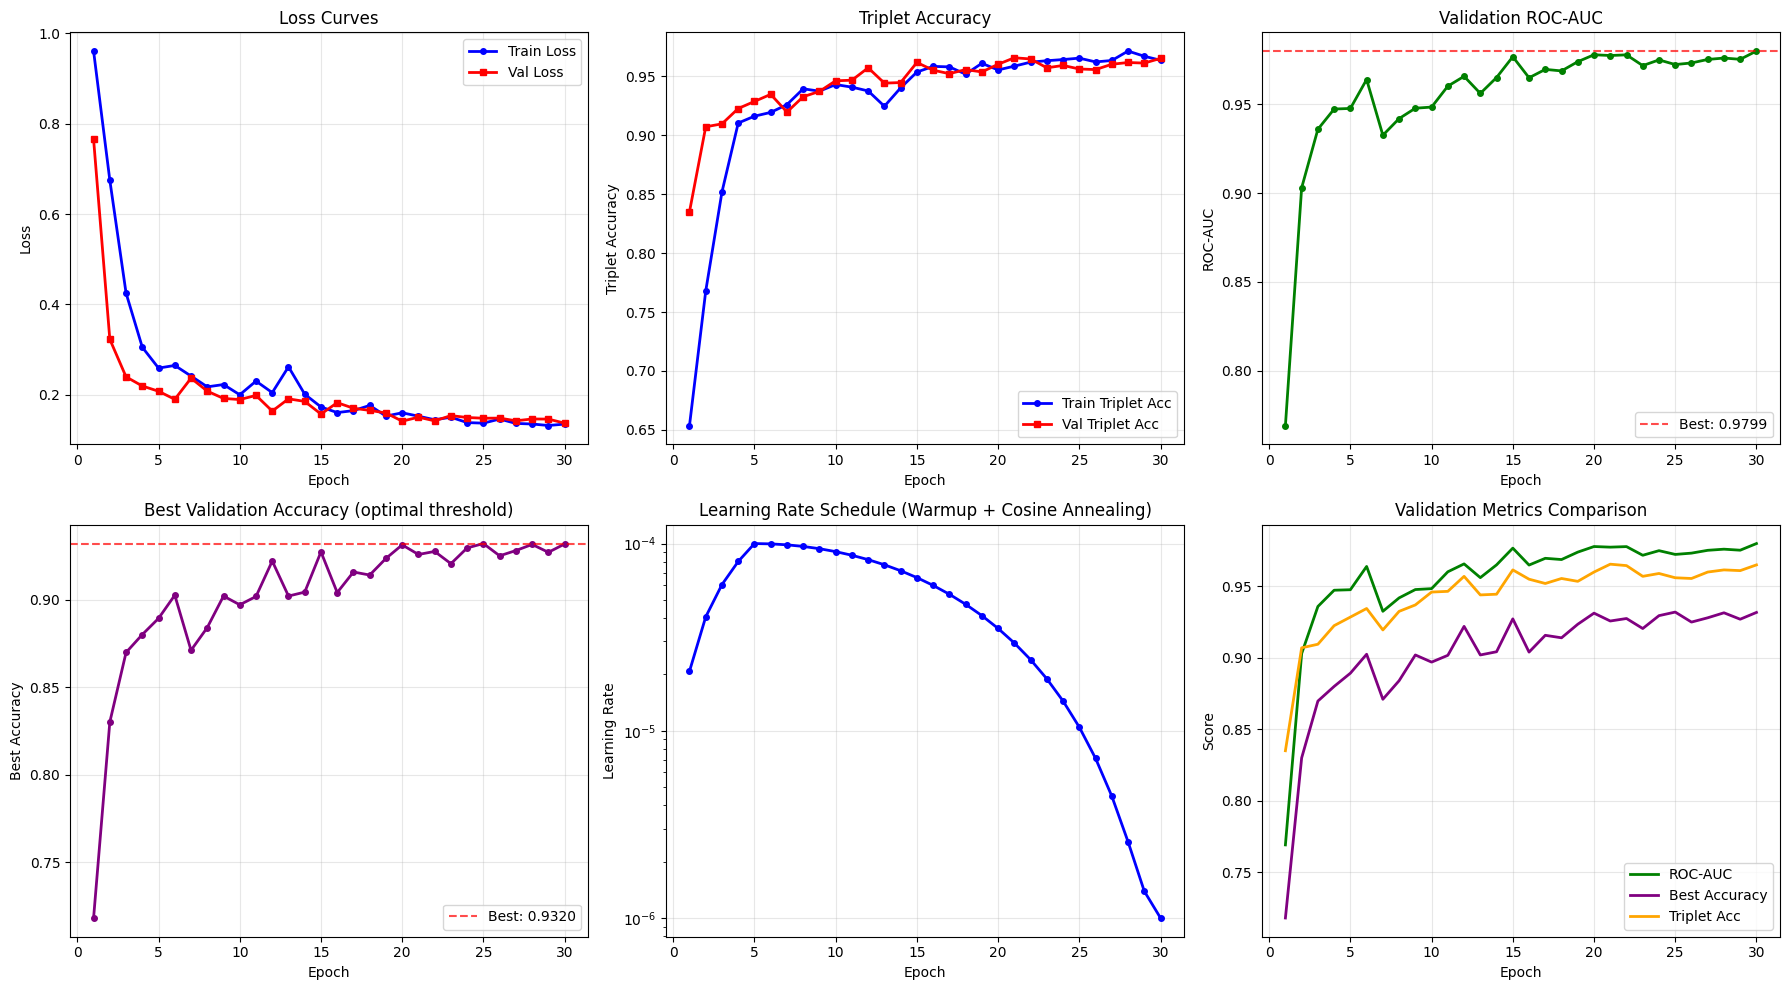

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

epochs = range(1, len(history_224['train_loss']) + 1)

# 1. Loss Curves
axes[0, 0].plot(epochs, history_224['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, history_224['val_loss'], 'r-s', label='Val Loss', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Triplet Accuracy
axes[0, 1].plot(epochs, history_224['train_triplet_accuracy'], 'b-o', label='Train Triplet Acc', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, history_224['val_triplet_accuracy'], 'r-s', label='Val Triplet Acc', linewidth=2, markersize=4)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Triplet Accuracy')
axes[0, 1].set_title('Triplet Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. ROC-AUC
axes[0, 2].plot(epochs, history_224['val_roc_auc'], 'g-o', linewidth=2, markersize=4)
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('ROC-AUC')
axes[0, 2].set_title('Validation ROC-AUC')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].axhline(y=max(history_224['val_roc_auc']), color='r', linestyle='--', alpha=0.7,
                   label=f"Best: {max(history_224['val_roc_auc']):.4f}")
axes[0, 2].legend()

# 4. Best Validation Accuracy
axes[1, 0].plot(epochs, history_224['val_best_accuracy'], 'purple', marker='o', linewidth=2, markersize=4)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Best Accuracy')
axes[1, 0].set_title('Best Validation Accuracy (optimal threshold)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=max(history_224['val_best_accuracy']), color='r', linestyle='--', alpha=0.7,
                   label=f"Best: {max(history_224['val_best_accuracy']):.4f}")
axes[1, 0].legend()

# 5. Learning Rate Schedule
axes[1, 1].plot(epochs, history_224['lr'], 'b-o', linewidth=2, markersize=4)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate Schedule (Warmup + Cosine Annealing)')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

# 6. Combined metrics
axes[1, 2].plot(epochs, history_224['val_roc_auc'], 'g-', label='ROC-AUC', linewidth=2)
axes[1, 2].plot(epochs, history_224['val_best_accuracy'], 'purple', label='Best Accuracy', linewidth=2)
axes[1, 2].plot(epochs, history_224['val_triplet_accuracy'], 'orange', label='Triplet Acc', linewidth=2)
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Score')
axes[1, 2].set_title('Validation Metrics Comparison')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics_224.png', dpi=150, bbox_inches='tight')
plt.show()